### 1.Import Data 

In [1]:
from src.data.data import CTScanFolderDataset
from src.transforms.ct_transforms import get_train_transforms,get_eval_transforms

train_transform = get_train_transforms(224)
val_transform = get_eval_transforms(224)

trainDataSet = CTScanFolderDataset("data/train",train_transform)
testDataSet = CTScanFolderDataset("data/test",val_transform)
validDataSet = CTScanFolderDataset("data/valid",val_transform)

print("Number of train samples:", len(trainDataSet))
print("Number of test samples:", len(testDataSet))
print("Number of validation samples:", len(validDataSet))

print("Classes:", trainDataSet.classes)
print("Mapping:", trainDataSet.class_to_idx)

sample = trainDataSet[0]
print(sample["image"].shape)
print(sample["label"])

Number of train samples: 613
Number of test samples: 315
Number of validation samples: 72
Classes: ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
Mapping: {'adenocarcinoma': 0, 'large.cell.carcinoma': 1, 'normal': 2, 'squamous.cell.carcinoma': 3}
torch.Size([3, 224, 224])
0


In [ ]:
from src.plot.plot import plot_one_image_per_class

plot_one_image_per_class(trainDataSet)

In [ ]:
from src.data.dataLoader import create_dataloaders

train_loader, valid_loader, test_loader, classes = create_dataloaders(
    train_dir="data/train",
    valid_dir="data/valid",
    test_dir="data/test",
    image_size=224,
    batch_size=32,
    num_workers=0
)

batch = next(iter(train_loader))

images = batch["image"]
labels = batch["label"]

print("Classes:", classes)
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Classes: ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([0, 1, 0, 3, 0, 1, 0, 3, 0, 2, 0, 1, 0, 2, 1, 2, 0, 1, 3, 1, 0, 1, 1, 1,
        3, 1, 1, 3, 3, 0, 0, 2])


c:\Users\SWS\Desktop\Project\Cnn\Cnn\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


### 2. Check Class Imbalance

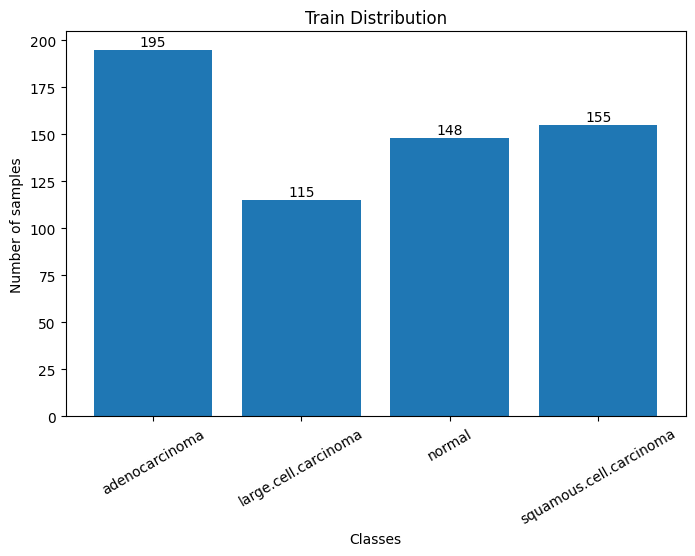

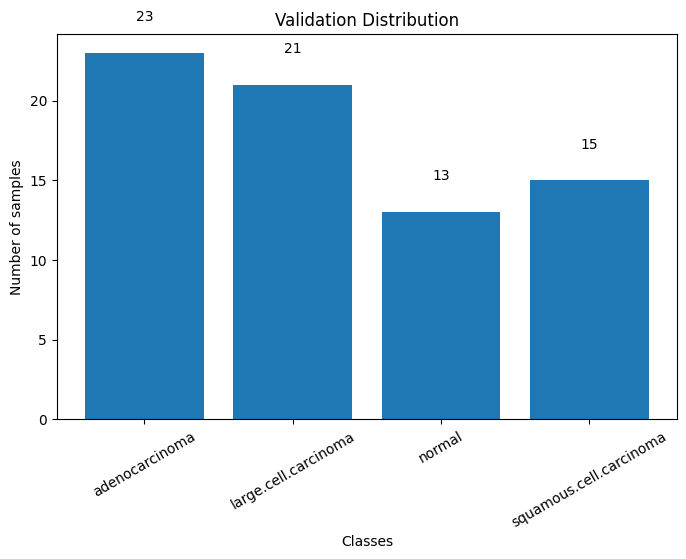

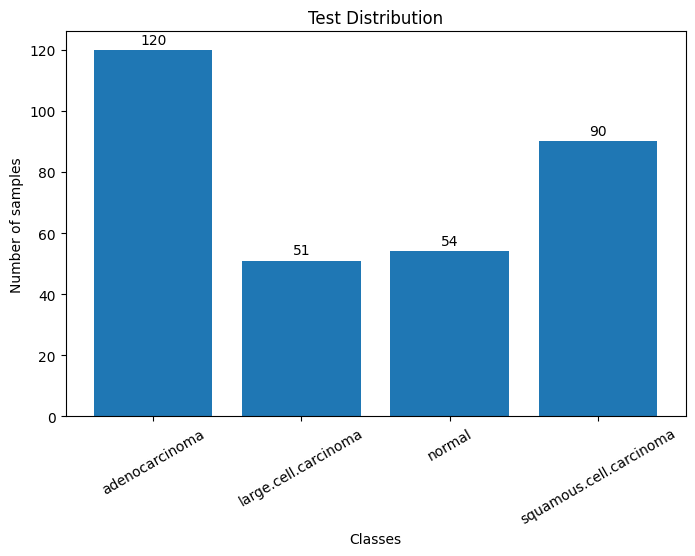

In [ ]:
from src.plot.plot import plot_class_distribution

plot_class_distribution(trainDataSet, "Train Distribution")
plot_class_distribution(validDataSet, "Validation Distribution")
plot_class_distribution(testDataSet, "Test Distribution")

In [ ]:
import torch
from src.model.cnn_baseline import CNNBaseline

model = CNNBaseline(num_classes=4)

batch = next(iter(train_loader))
images = batch["image"]

outputs = model(images)

print(outputs.shape)

torch.Size([32, 4])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from src.model.cnn_baseline import CNNBaseline
from src.training.training import train_one_epoch, validate_one_epoch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNBaseline(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 10

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    valid_loss, valid_acc = validate_one_epoch(
        model, valid_loader, criterion, device
    )

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")


Epoch 1/10


Training:  75%|███████▌  | 15/20 [00:13<00:04,  1.10it/s]


KeyboardInterrupt: 

In [ ]:
print("Total params:", model.count_parameters())
print("Trainable params:", model.count_trainable_parameters())

Total params: 6516548
Trainable params: 6516548
